In [4]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [5]:
# Read files
df1 = pd.read_csv("/content/drive/MyDrive/topic_modeling_kbmi4/BCAMobile_reviews_cleaned.csv")
df2 = pd.read_csv("/content/drive/MyDrive/topic_modeling_kbmi4/BRImo_reviews_cleaned.csv")
df3 = pd.read_csv("/content/drive/MyDrive/topic_modeling_kbmi4/Wondr_BNI_reviews_cleaned.csv")
df4 = pd.read_csv("/content/drive/MyDrive/topic_modeling_kbmi4/livin_mandiri_reviews_cleaned.csv")
# Sample 5000 rows from each (random)
df1_sample = df1.sample(n=5000, random_state=42)
df2_sample = df2.sample(n=5000, random_state=42)
df3_sample = df3.sample(n=5000, random_state=42)
df4_sample = df4.sample(n=5000, random_state=42)

# Combine into one dataframe
df = pd.concat([df1_sample, df2_sample, df3_sample, df4_sample], ignore_index=True)

In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['score']
)

In [10]:
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")
model = AutoModel.from_pretrained("indolem/indobert-base-uncased")

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "indolem/indobert-base-uncased",
        num_labels=4
    )

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

In [11]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # Using 'weighted' average to account for class imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [12]:
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len=128):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = self.labels[item]
        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [13]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.0 MB/s eta 0:00:00


In [17]:
train_dataset = ReviewDataset(train_df.content_cleaned.tolist(), train_df.score.tolist(), tokenizer)
val_dataset = ReviewDataset(val_df.content_cleaned.tolist(), val_df.score.tolist(), tokenizer)
from transformers import EarlyStoppingCallback
# 4. Training Configuration
# Using hyperparameters similar to standard IndoBERT research.
# 3. Training Arguments with Logging
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/indobert_final_results',
    num_train_epochs=20,
    per_device_train_batch_size=32, # Increased for T4
    fp16=True,                     # Enabled for T4 speed boost
    per_device_eval_batch_size=32,

    # These two MUST match for load_best_model_at_end to work
    eval_strategy="epoch",     # Run evaluation every epoch
    save_strategy="epoch",           # Save a checkpoint every epoch
    save_total_limit = 1,
    logging_strategy="epoch",        # Log metrics every epoch
    learning_rate=2e-5,              # Standard IndoBERT fine-tuning rate

    load_best_model_at_end=True,     # Load the model with the best eval_loss
    metric_for_best_model="f1",      # Optional: tell it to pick the "best" based on F1
    greater_is_better=True,          # Since F1 is "higher = better"
)

trainer = Trainer(
    model_init=model_init,           # Use the function, not the model object
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)
def my_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 6e-6, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
    }
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=my_hp_space,
    n_trials=3 # Keep low on CPU; Increase to 20+ on GPU
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-05-04 05:52:40,21

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Error during conversion: AttributeError("'str' object has no attribute 'decode'")
BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.835451,0.808961,0.686000,0.558240,0.470596,0.686000
2,0.828520,0.833360,0.686000,0.558240,0.470596,0.686000
3,0.822510,0.817175,0.686000,0.558240,0.470596,0.686000
4,0.796112,0.833040,0.686000,0.558240,0.470596,0.686000
5,0.795548,0.829452,0.675750,0.584802,0.528126,0.675750
6,0.775173,0.802233,0.682250,0.594310,0.540324,0.682250
7,0.748333,0.814126,0.670500,0.606604,0.554428,0.670500
8,0.725749,0.830124,0.661750,0.595501,0.618303,0.661750
9,0.695612,0.848452,0.641000,0.598264,0.564374,0.641000
10,0.661012,0.846448,0.647500,0.606667,0.631216,0.647500


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [19]:
import os
import json

base_path = '/content/drive/MyDrive/indobert_final_results'
best_f1 = -1
best_run_id = None
best_state_path = None

# 1. Iterate through run-0, run-1, run-2
for run_folder in os.listdir(base_path):
    if run_folder.startswith('run-'):
        run_path = os.path.join(base_path, run_folder)

        # 2. Search for trainer_state.json in the run folder OR its checkpoints
        possible_paths = [os.path.join(run_path, 'trainer_state.json')]

        # Add all checkpoint subfolders to the search list
        if os.path.isdir(run_path):
            checkpoints = [d for d in os.listdir(run_path) if d.startswith('checkpoint-')]
            for ckpt in checkpoints:
                possible_paths.append(os.path.join(run_path, ckpt, 'trainer_state.json'))

        # 3. Check each path for the highest F1
        for state_path in possible_paths:
            if os.path.exists(state_path):
                with open(state_path, 'r') as f:
                    try:
                        state_data = json.load(f)
                        # Extract eval_f1 from the logs
                        trial_f1s = [log['eval_f1'] for log in state_data['log_history'] if 'eval_f1' in log]

                        if trial_f1s:
                            max_f1_in_file = max(trial_f1s)
                            if max_f1_in_file > best_f1:
                                best_f1 = max_f1_in_file
                                best_run_id = run_folder
                                best_state_path = state_path
                    except Exception as e:
                        print(f"Skipping {state_path} due to error: {e}")

print(f"✅ Recovery Complete!")
print(f"Best Folder: {best_run_id}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Path to use for Graphing: {best_state_path}")

✅ Recovery Complete!
Best Folder: run-2
Best F1 Score: 0.6271
Path to use for Graphing: /content/drive/MyDrive/indobert_final_results/run-2/checkpoint-9000/trainer_state.json


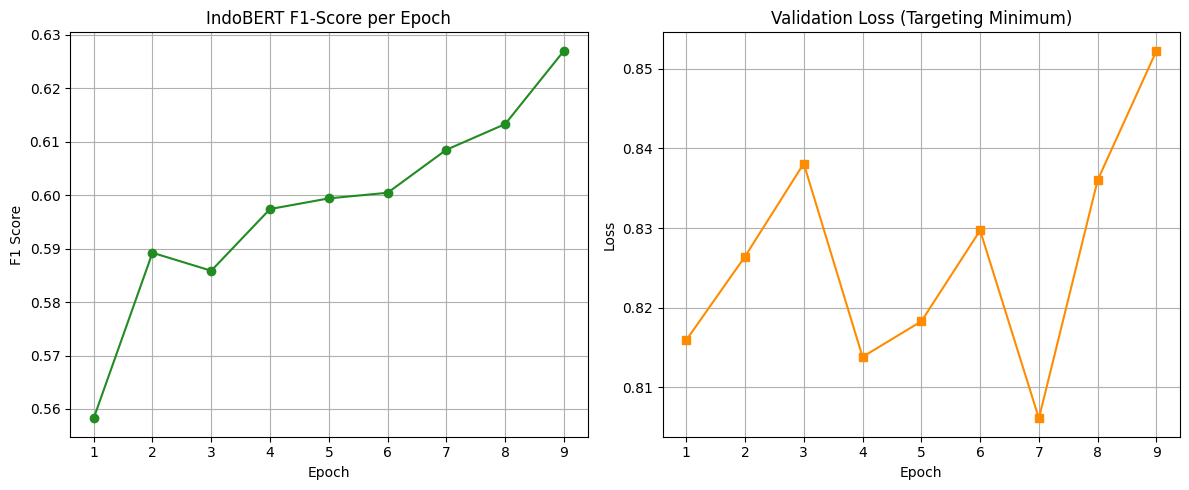

In [20]:
import json
import matplotlib.pyplot as plt

# The specific path you recovered
state_file = '/content/drive/MyDrive/indobert_final_results/run-2/checkpoint-9000/trainer_state.json'

with open(state_file, 'r') as f:
    data = json.load(f)

# Extracting evaluation metrics
epochs = [log['epoch'] for log in data['log_history'] if 'eval_f1' in log]
f1_scores = [log['eval_f1'] for log in data['log_history'] if 'eval_f1' in log]
val_loss = [log['eval_loss'] for log in data['log_history'] if 'eval_loss' in log]

plt.figure(figsize=(12, 5))

# Plot F1 Score
plt.subplot(1, 2, 1)
plt.plot(epochs, f1_scores, marker='o', color='forestgreen', label='F1-Score')
plt.title('IndoBERT F1-Score per Epoch')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss, marker='s', color='darkorange', label='Validation Loss')
plt.title('Validation Loss (Targeting Minimum)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Load from the directory CONTAINING the trainer_state.json
model_path = '/content/drive/MyDrive/indobert_final_results/run-2/checkpoint-9000/'

best_model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")

print("✅ Best Model Loaded Successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Best Model Loaded Successfully!


In [22]:
final_export_path = '/content/drive/MyDrive/indobert_sentiment_final'

best_model.save_pretrained(final_export_path)
tokenizer.save_pretrained(final_export_path)

print(f"🚀 Model consolidated at {final_export_path}. Use this path for BERTopic!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🚀 Model consolidated at /content/drive/MyDrive/indobert_sentiment_final. Use this path for BERTopic!


In [25]:
all_run_data = []

for folder in sorted(os.listdir(base_path)):
    if folder.startswith('run-'):
        state_path = os.path.join(base_path, folder, 'trainer_state.json')
        if not os.path.exists(state_path): # Check checkpoints if not in root
            ckpt_folders = [d for d in os.listdir(os.path.join(base_path, folder)) if 'checkpoint' in d]
            if ckpt_folders:
                state_path = os.path.join(base_path, folder, ckpt_folders[-1], 'trainer_state.json')

        if os.path.exists(state_path):
            with open(state_path, 'r') as f:
                logs = json.load(f)['log_history']
                for log in logs:
                    if 'eval_f1' in log:
                        all_run_data.append({
                            'Trial': folder,
                            'Epoch': log['epoch'],
                            'Eval_Loss': log.get('eval_loss'),
                            'F1_Score': log.get('eval_f1'),
                            'Accuracy': log.get('eval_accuracy')
                        })

df_results = pd.DataFrame(all_run_data)
# Sort to show the best results at the top
print(df_results.sort_values(by='F1_Score', ascending=False).to_markdown())

|    | Trial   |   Epoch |   Eval_Loss |   F1_Score |   Accuracy |
|---:|:--------|--------:|------------:|-----------:|-----------:|
| 31 | run-2   |       9 |    0.852247 |   0.627051 |    0.6405  |
| 22 | run-1   |      10 |    0.850943 |   0.62097  |    0.65775 |
| 12 | run-0   |      13 |    0.990168 |   0.619752 |    0.6425  |
| 20 | run-1   |       8 |    0.822756 |   0.618289 |    0.65975 |
| 10 | run-0   |      11 |    0.875973 |   0.61815  |    0.64975 |
| 30 | run-2   |       8 |    0.836021 |   0.613322 |    0.68075 |
| 19 | run-1   |       7 |    0.804857 |   0.611783 |    0.684   |
| 16 | run-1   |       4 |    0.792309 |   0.609405 |    0.6875  |
| 29 | run-2   |       7 |    0.806116 |   0.608513 |    0.68175 |
| 11 | run-0   |      12 |    0.95988  |   0.608433 |    0.657   |
| 17 | run-1   |       5 |    0.796184 |   0.607892 |    0.67325 |
|  9 | run-0   |      10 |    0.846448 |   0.606667 |    0.6475  |
| 18 | run-1   |       6 |    0.792973 |   0.606655 |    0.679

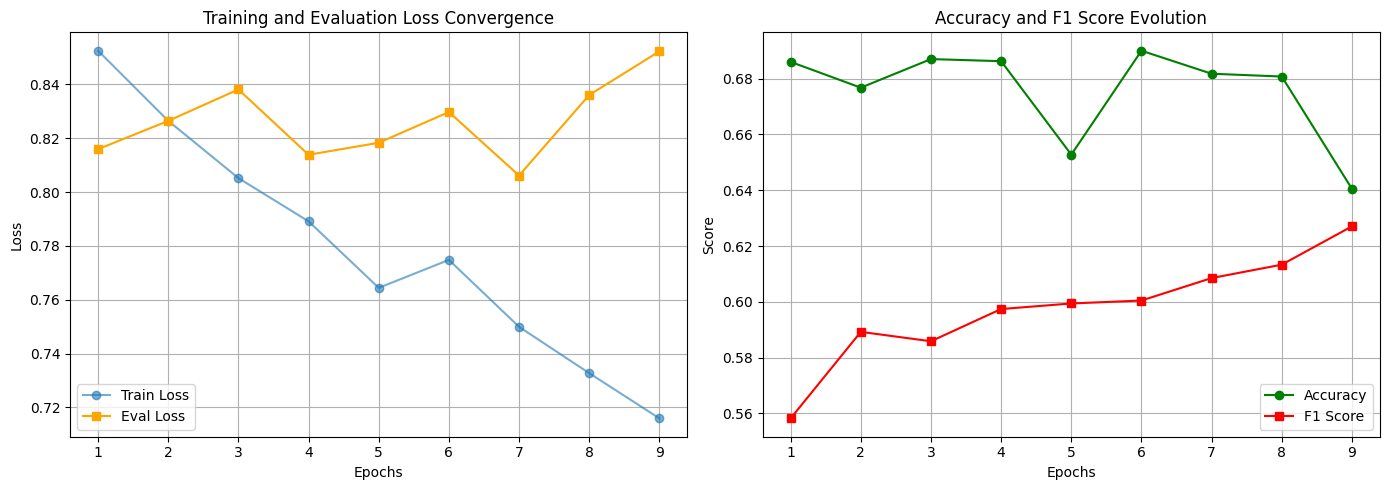

In [23]:
import json
import matplotlib.pyplot as plt

# Load the specific state file from your best run
state_path = '/content/drive/MyDrive/indobert_final_results/run-2/checkpoint-9000/trainer_state.json'

with open(state_path, 'r') as f:
    state_data = json.load(f)

# Initialize lists
epochs_eval = []
eval_loss = []
accuracy = []
f1_scores = []
epochs_train = []
train_loss = []

# Parse the log history correctly
for entry in state_data['log_history']:
    if 'eval_loss' in entry:
        epochs_eval.append(entry['epoch'])
        eval_loss.append(entry['eval_loss'])
        accuracy.append(entry['eval_accuracy'])
        f1_scores.append(entry['eval_f1'])
    elif 'loss' in entry:
        epochs_train.append(entry['epoch'])
        train_loss.append(entry['loss'])

# 6. Plotting the Graphs
plt.figure(figsize=(14, 5))

# Graph A: Loss (Training vs Evaluation)
plt.subplot(1, 2, 1)
plt.plot(epochs_train, train_loss, label='Train Loss', marker='o', alpha=0.6)
plt.plot(epochs_eval, eval_loss, label='Eval Loss', marker='s', color='orange')
plt.title('Training and Evaluation Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Graph B: Performance Metrics
plt.subplot(1, 2, 2)
plt.plot(epochs_eval, accuracy, label='Accuracy', marker='o', color='green')
plt.plot(epochs_eval, f1_scores, label='F1 Score', marker='s', color='red')
plt.title('Accuracy and F1 Score Evolution')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

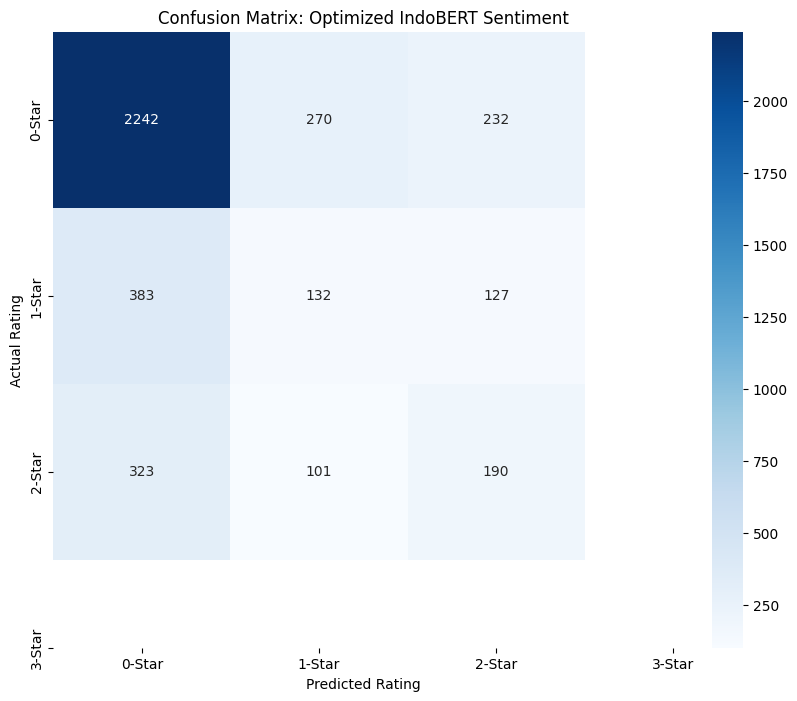

In [27]:
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import seaborn as sns

# 1. Define the missing loader
# Using batch_size=32 to match your T4 GPU capabilities
val_loader = DataLoader(val_dataset, batch_size=32)

# 2. Get Predictions
best_model.to('cuda')
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        inputs = batch['input_ids'].to('cuda')
        mask = batch['attention_mask'].to('cuda')
        labels = batch['labels'].to('cuda')
        outputs = best_model(inputs, attention_mask=mask)
        all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Plotting the Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0-Star', '1-Star', '2-Star', '3-Star'],
            yticklabels=['0-Star', '1-Star', '2-Star', '3-Star'])
plt.title('Confusion Matrix: Optimized IndoBERT Sentiment')
plt.ylabel('Actual Rating')
plt.xlabel('Predicted Rating')
plt.show()

# BERTopic


In [29]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.8 MB/s eta 0:00:00


In [31]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer


In [32]:
import joblib

In [33]:
# 1. Load the "Expert" Embedding Model
embedding_model = SentenceTransformer('/content/drive/MyDrive/indobert_sentiment_final')

# 2. Configure for 20k rows
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=20, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 3. Handle Indonesian Stopwords
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
indonesian_stopwords = stopwords.words('indonesian')
vectorizer_model = CountVectorizer(stop_words=indonesian_stopwords)

# 4. Initialize and Run
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

docs = train_df.content_cleaned.tolist()
topics, probs = topic_model.fit_transform(docs)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/indobert_sentiment_final
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
2026-05-04 08:02:39,826 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/500 [00:00<?, ?it/s]

2026-05-04 08:03:09,678 - BERTopic - Embedding - Completed ✓
2026-05-04 08:03:09,679 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 08:04:15,355 - BERTopic - Dimensionality - Completed ✓
2026-05-04 08:04:15,357 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 08:04:29,273 - BERTopic - Cluster - Completed ✓
2026-05-04 08:04:29,296 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 08:04:29,794 - BERTopic - Representation - Completed ✓


In [34]:
# Create a dedicated directory for exports
export_dir = '/content/drive/MyDrive/indobert_sentiment_final/bertopic_outputs'
os.makedirs(export_dir, exist_ok=True)

# 1. Save the actual Model (The "Brain")
# This allows you to run .visualize_topics() later without re-training
topic_model.save(f"{export_dir}/full_bertopic_model", serialization="safetensors", save_ctfidf=True)

# 2. Export the Topic Results Table
# This is the "Gold Record" for your thesis data analysis
topic_info = topic_model.get_topic_info()
topic_info.to_csv(f"{export_dir}/topic_definitions.csv", index=False)

# 3. Export the Master Dataset (Reviews + Topics + Probabilities)
# We join the topics back to your original star ratings
final_results_df = train_df.copy()
final_results_df['Topic'] = topics
# Save the probability of the most likely topic for each review
final_results_df['Topic_Probability'] = [max(p) if p is not None else 0 for p in probs]

final_results_df.to_csv(f"{export_dir}/final_labeled_reviews_20k.csv", index=False)

# 4. Save Probabilities Matrix (Optional but useful for heatmaps)
joblib.dump(probs, f"{export_dir}/probabilities_matrix.pkl")

print(f"✅ All assets exported to {export_dir}")

✅ All assets exported to /content/drive/MyDrive/indobert_sentiment_final/bertopic_outputs


In [44]:
topic_info = pd.read_csv(f"{export_dir}/topic_definitions.csv")

# Look at the top 10 discovered topics
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1581,-1_nya_masuk_mobile_gak,"['nya', 'masuk', 'mobile', 'gak', 'transaksi',...",['gimana abis update kok fitur tarik tunai nya...
1,0,1430,0_jelek_buruk_mengecewakan_kecewa,"['jelek', 'buruk', 'mengecewakan', 'kecewa', '...","['aplikasi nya jelek gk di buka', 'aplikasi me..."
2,1,822,1_wajah_verifikasi_gagal_aneh,"['wajah', 'verifikasi', 'gagal', 'aneh', 'aja'...","['verifikasi wajah susah banget', 'kalo ganti ..."
3,2,580,2_ribet_udah_bca_aja,"['ribet', 'udah', 'bca', 'aja', 'wajah', 'aneh...",['mau verifikasi ulang ribet banget pulsa dah ...
4,3,521,3_parah_payah_merugikan_bca,"['parah', 'payah', 'merugikan', 'bca', 'buruk'...","['sangat payah buka rekening bank nya', 'parah..."
5,4,438,4_wajah_gagal_aneh_aja,"['wajah', 'gagal', 'aneh', 'aja', 'saldo', 'bi...",['mau login hp baru verifikasi wajah gagal ter...
6,5,394,5_aneh_aja_banget_jelek,"['aneh', 'aja', 'banget', 'jelek', 'saldo', 'd...","['tiap jam selalu error aneh', 'aneh gk daftar..."
7,6,266,6_eror_pasword_yg_login,"['eror', 'pasword', 'yg', 'login', 'transaksi'...","['suka eror padahal jaringan bagus', 'banyak e..."
8,7,238,7_parah_buruk_payah_bca,"['parah', 'buruk', 'payah', 'bca', 'jelek', 's...",['sangat buruk gagal transaksi saldo balik hil...
9,8,206,8_ditek_potongan_anggota_lpg,"['ditek', 'potongan', 'anggota', 'lpg', 'kali'...",['kalau ada pilihinan bank selain mandiri gaji...


In [45]:
topic_model.visualize_topics()

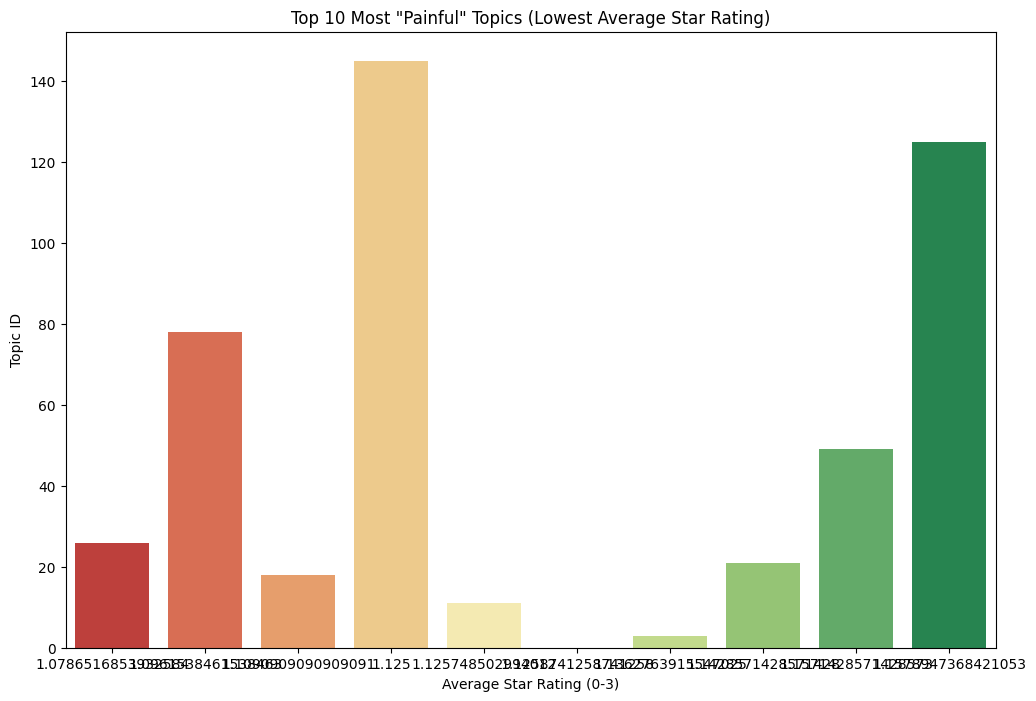

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate average star rating per topic
topic_sentiment = df.groupby('Topic')['score'].agg(['mean', 'count']).reset_index()
# Filter out Topic -1 (outliers) and small topics for a cleaner graph
topic_sentiment = topic_sentiment[topic_sentiment['Topic'] != -1].sort_values('mean')

# 2. Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=topic_sentiment.head(10), x='mean', y='Topic', palette='RdYlGn')
plt.title('Top 10 Most "Painful" Topics (Lowest Average Star Rating)')
plt.xlabel('Average Star Rating (0-3)')
plt.ylabel('Topic ID')
plt.show()

In [48]:
for i, repo in enumerate(topic_info['Representative_Docs'].head(21)):
    topic_id = topic_info.iloc[i]['Topic']
    print(f"Topic {topic_id}: {repo}")

Topic -1: ['gimana abis update kok fitur tarik tunai nya gak buka jadinya tidak untuk tarik tunai kadang gak untuk transfer mohon di perbaiki dong', 'butuh banget malah ga di pakai bagus bni yg dulu pada wondr', 'lemot banget pas buka apk nya padahal sinyal bagus']
Topic 0: ['aplikasi nya jelek gk di buka', 'aplikasi mengecewakan padahal menggunakan mandiri banyak pelayanan aplikasinya sangat buruk layanan mandiri call tidak memberi solusi yg tepat parah banget', 'aplikasi jelek buruk gak di buka']
Topic 1: ['verifikasi wajah susah banget', 'kalo ganti hp makin susah verifikasi wajah ribet banget makin ribet aplikasinya', 'susah buat verifikasi wajah gagal mulu']
Topic 2: ['mau verifikasi ulang ribet banget pulsa dah kesedot buat sms gak sms kode otp masuk pas balik buka bca mobile nya malah balik menu awal gitu aja terus udah coba x', 'bank bri knp org ngurus atm yg hilang tertelan ingin mengganti kartu baru kantor bri selalu tdk dan alasan tdk kartunya mksdnya apa sih ktanya bank rak